In [68]:
%load_ext autoreload
%autoreload 2
import models.moe

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [69]:
import json
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import pandas as pd

from config import ExperimentConfig
from models.moe import MoELayer
from utils.training import set_seed, get_device
from utils.hessian import compute_spectral_norms
from utils.plotting import apply_plot_style, ensure_dir

In [70]:
cfg = ExperimentConfig()

# базовые настройки standalone-эксперимента
d = 16
d_ff = 32
num_experts = 4
top_k = 2
gating_type = "softmax"   # сначала только softmax

n_train = 2048
n_test = 512
batch_size = 64
epochs = 30
lr = 1e-3
noise_std = 0.0

power_iters = 80
power_tol = 1e-6

output_root = Path("outputs") / "standalone_moe_bound"
fig_dir = ensure_dir(output_root / "figures")
json_dir = ensure_dir(output_root / "json")
table_dir = ensure_dir(output_root / "tables")
ckpt_dir = ensure_dir(output_root / "checkpoints")

NUM_PROBE_ARTICLE = 16
POWER_ITERS_ARTICLE = 50
POWER_TOL_ARTICLE = 1e-6

E_values = [2, 4, 8, 16, 32, 64, 128]

In [71]:
set_seed(42)
device = get_device(None)
apply_plot_style(font_size=14, use_tex=False)

print("Using device:", device)
print("Output dir:", output_root)

Using device: cpu
Output dir: outputs\standalone_moe_bound


In [72]:
import torch
import torch.nn as nn


class HalfSquaredError(nn.Module):
    """
    loss = 0.5 * mean ||pred - target||^2

    Для одного объекта Hessian по output равен I.
    """
    def __init__(self, reduction="mean"):
        super().__init__()
        self.reduction = reduction

    def forward(self, pred, target):
        per_sample = 0.5 * ((pred - target) ** 2).sum(dim=-1)

        if self.reduction == "mean":
            return per_sample.mean()
        elif self.reduction == "sum":
            return per_sample.sum()
        else:
            raise ValueError(f"Unsupported reduction: {self.reduction}")

In [73]:
class StandaloneMoERegressor(nn.Module):
    def __init__(self, d=16, d_ff=32, num_experts=4, top_k=2, gating_type="softmax"):
        super().__init__()
        self.moe = MoELayer(
            d=d,
            d_ff=d_ff,
            num_experts=num_experts,
            top_k=top_k,
            gating_type=gating_type,
        )

    def forward(self, x, return_gates=False):
        return self.moe(x, return_gates=return_gates)

In [74]:
def make_teacher_student_regression_data(
    n_train=2048,
    n_test=512,
    d=16,
    d_ff=32,
    num_experts=4,
    top_k=2,
    gating_type="softmax",
    batch_size=64,
    noise_std=0.0,
    device="cpu",
    teacher_model=None
):
    """
    Если teacher_model не None, используется она.
    Иначе создаётся новая StandaloneMoERegressor с параметрами num_experts, top_k.
    Возвращает teacher, train_loader, test_loader.
    """
    if teacher_model is not None:
        teacher = teacher_model
    else:
        teacher = StandaloneMoERegressor(
            d=d,
            d_ff=d_ff,
            num_experts=num_experts,
            top_k=top_k,
            gating_type=gating_type,
        ).to(device)
        teacher.eval()
        for p in teacher.parameters():
            p.requires_grad_(False)

    X_train = torch.randn(n_train, d, device=device)
    X_train = X_train / X_train.norm(dim=1, keepdim=True).clamp_min(1e-8)
    X_test = torch.randn(n_test, d, device=device)
    X_test = X_test / X_test.norm(dim=1, keepdim=True).clamp_min(1e-8)

    with torch.no_grad():
        Y_train = teacher(X_train)
        Y_test = teacher(X_test)

        if noise_std > 0:
            Y_train = Y_train + noise_std * torch.randn_like(Y_train)
            Y_test = Y_test + noise_std * torch.randn_like(Y_test)

    train_ds = TensorDataset(X_train.cpu(), Y_train.cpu())
    test_ds = TensorDataset(X_test.cpu(), Y_test.cpu())

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return teacher, train_loader, test_loader

In [39]:
teacher, train_loader, test_loader = make_teacher_student_regression_data(
    n_train=n_train,
    n_test=n_test,
    d=d,
    d_ff=d_ff,
    num_experts=num_experts,
    top_k=top_k,
    gating_type=gating_type,
    batch_size=batch_size,
    noise_std=noise_std,
    device=device,
)

student = StandaloneMoERegressor(
    d=d,
    d_ff=d_ff,
    num_experts=num_experts,
    top_k=top_k,
    gating_type=gating_type,
).to(device)

criterion = HalfSquaredError(reduction="mean")
optimizer = optim.Adam(student.parameters(), lr=lr)

print(student)
print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

StandaloneMoERegressor(
  (moe): MoELayer(
    (experts): ModuleList(
      (0-3): 4 x FFN(
        (fc1): Linear(in_features=16, out_features=32, bias=True)
        (act): ReLU()
        (fc2): Linear(in_features=32, out_features=16, bias=True)
      )
    )
    (router): Linear(in_features=16, out_features=4, bias=True)
  )
)
Train batches: 32
Test batches: 8


In [75]:
def train_one_epoch_regression(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def evaluate_regression(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        pred = model(x)
        loss = criterion(pred, y)
        total_loss += loss.item()

    return total_loss / len(loader)

In [41]:
x0, y0 = next(iter(test_loader))
x0 = x0.to(device)
y0 = y0.to(device)

baseline_norms = compute_spectral_norms(
    model=student,
    x=x0[:1],
    y=y0[:1],
    loss_fn=criterion,
    params=None,
    num_iters=power_iters,
    tol=power_tol,
    device=device,
)

baseline_norms

{'H_norm': 0.7213394641876221,
 'G_norm': 0.6801136136054993,
 'rho': 0.9428481975146727,
 'num_params': 4356}

In [42]:
history = []

for epoch in range(epochs):
    train_loss = train_one_epoch_regression(student, train_loader, optimizer, criterion, device)
    test_loss = evaluate_regression(student, test_loader, criterion, device)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "test_loss": test_loss,
    })

    if epoch % 5 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch:3d} | train_loss={train_loss:.6f} | test_loss={test_loss:.6f}")

Epoch   0 | train_loss=0.024812 | test_loss=0.007817
Epoch   5 | train_loss=0.001155 | test_loss=0.001160
Epoch  10 | train_loss=0.000783 | test_loss=0.000833
Epoch  15 | train_loss=0.000597 | test_loss=0.000656
Epoch  20 | train_loss=0.000490 | test_loss=0.000554
Epoch  25 | train_loss=0.000420 | test_loss=0.000484
Epoch  29 | train_loss=0.000379 | test_loss=0.000438


In [43]:
torch.save(student.state_dict(), ckpt_dir / "student_final.pth")

with open(json_dir / "train_history.json", "w", encoding="utf-8") as f:
    json.dump(history, f, indent=2)

print("Saved model and history.")

Saved model and history.


In [76]:
def spectral_norm_weight(W):
    return torch.linalg.matrix_norm(W.detach(), ord=2).item()


# def compute_softmax_moe_bound(model, x):
#     """
#     Теоретическая граница для standalone MoE + 0.5 ||z-y||^2.
#     Здесь M_A = 1.

#     x: [d] или [1, d]
#     """
#     if x.dim() == 2:
#         if x.shape[0] != 1:
#             raise ValueError("Pass a single sample x with shape [d] or [1, d].")
#         x = x[0]

#     moe = model.moe

#     M_x = x.norm().item()
#     M_A = 1.0

#     M1 = max(spectral_norm_weight(expert.fc1.weight) for expert in moe.experts)
#     M2 = max(spectral_norm_weight(expert.fc2.weight) for expert in moe.experts)

#     bound_improved = M_A * (M_x ** 2) * (
#         M1 ** 2 + M2 ** 2 + M1 ** 2 * M2 ** 2 * M_x ** 2
#     )

#     bound_crude_E = M_A * (M_x ** 2) * (
#         M1 ** 2
#         + moe.num_experts * M2 ** 2
#         + moe.num_experts * M1 ** 2 * M2 ** 2 * M_x ** 2
#     )

#     return {
#         "M_x": M_x,
#         "M_A": M_A,
#         "M1": M1,
#         "M2": M2,
#         "bound_improved": bound_improved,
#         "bound_crude_E": bound_crude_E,
#     }

@torch.no_grad()
def compute_softmax_moe_bounds(model, x):
    """
    Теоретические границы для одного объекта x.

    bound_no_sg:
        M_A M_x^2 (M_1^2 + M_2^2 + M_1^2 M_2^2 M_x^2)

    bound_theorem:
        M_A M_x^2 S_g (M_1^2 + M_2^2 + 4 M_1^2 M_2^2 M_x^2)

    Здесь для loss = 0.5 ||z-y||^2 имеем M_A = 1.
    """
    if x.dim() == 2:
        if x.shape[0] != 1:
            raise ValueError("Pass a single sample x of shape [d] or [1, d].")
        x_single = x[0]
    else:
        x_single = x

    moe = model.moe
    M_x = x_single.norm().item()
    M_A = 1.0

    M1 = max(
        torch.linalg.matrix_norm(expert.fc1.weight.detach(), ord=2).item()
        for expert in moe.experts
    )
    M2 = max(
        torch.linalg.matrix_norm(expert.fc2.weight.detach(), ord=2).item()
        for expert in moe.experts
    )

    _, gates = moe(x_single.unsqueeze(0), return_gates=True)
    S_g = (gates ** 2).sum().item()

    base_term = M1 ** 2 + M2 ** 2 + M1 ** 2 * M2 ** 2 * M_x ** 2
    theorem_term = M1 ** 2 + M2 ** 2 + 4 * M1 ** 2 * M2 ** 2 * M_x ** 2

    bound_no_sg = M_A * (M_x ** 2) * base_term
    bound_theorem = M_A * (M_x ** 2) * S_g * theorem_term

    return {
        "M_x": M_x,
        "M_A": M_A,
        "M1": M1,
        "M2": M2,
        "S_g": S_g,
        "bound_no_sg": bound_no_sg,
        "bound_theorem": bound_theorem,

        # Backward-compatible aliases:
        "S_g2": S_g,
        "bound_improved": bound_no_sg,
        "bound_improved_gates": bound_theorem,
    }


# Чтобы старые cell тоже работали, если где-то осталось старое имя:
compute_softmax_moe_bound_with_gates = compute_softmax_moe_bounds

@torch.no_grad()
def compute_gate_stats(model, loader, device):
    """
    Вычисляет среднее по набору данных значение sum(g^2) 
    и среднее отдельных g_e (для контроля).
    """
    model.eval()
    total_sg2 = 0.0
    total_samples = 0
    
    for x, y in loader:
        x = x.to(device)
        out, gates = model(x, return_gates=True)  # gates shape: [batch, E] (т.к. x [B, D])
        sg2 = (gates ** 2).sum(dim=1)            # [batch]
        total_sg2 += sg2.sum().item()
        total_samples += x.size(0)
    
    avg_sg2 = total_sg2 / total_samples
    return avg_sg2

In [45]:
probe_batch_x, probe_batch_y = next(iter(test_loader))
probe_batch_x = probe_batch_x.to(device)
probe_batch_y = probe_batch_y.to(device)

num_probe = 12
probe_x = probe_batch_x[:num_probe]
probe_y = probe_batch_y[:num_probe]

print("Probe shape:", probe_x.shape, probe_y.shape)

Probe shape: torch.Size([12, 16]) torch.Size([12, 16])


In [77]:
def evaluate_probe_samples(
    model,
    probe_x,
    probe_y,
    loss_fn,
    device,
    power_iters=50,
    power_tol=1e-6,
):
    rows = []

    for i in range(len(probe_x)):
        x = probe_x[i:i + 1].to(device)
        y = probe_y[i:i + 1].to(device)

        norms = compute_spectral_norms(
            model=model,
            x=x,
            y=y,
            loss_fn=loss_fn,
            params=None,
            num_iters=power_iters,
            tol=power_tol,
            device=device,
        )

        bounds = compute_softmax_moe_bounds(model, x)

        bound_no_sg = bounds["bound_no_sg"]
        bound_theorem = bounds["bound_theorem"]

        rows.append({
            "sample_id": i,
            "H_norm": norms["H_norm"],
            "G_norm": norms["G_norm"],
            "rho": norms["rho"],

            "bound_no_sg": bound_no_sg,
            "bound_theorem": bound_theorem,

            "M_x": bounds["M_x"],
            "M1": bounds["M1"],
            "M2": bounds["M2"],
            "S_g": bounds["S_g"],

            "ratio_no_sg": norms["G_norm"] / bound_no_sg if bound_no_sg > 0 else None,
            "ratio_theorem": norms["G_norm"] / bound_theorem if bound_theorem > 0 else None,

            # Backward-compatible aliases:
            "S_g2": bounds["S_g"],
            "bound_improved": bound_no_sg,
            "bound_improved_gates": bound_theorem,
            "ratio_improved": norms["G_norm"] / bound_no_sg if bound_no_sg > 0 else None,
            "ratio_improved_gates": norms["G_norm"] / bound_theorem if bound_theorem > 0 else None,
        })

    return rows

In [47]:
probe_rows = evaluate_probe_samples(
    model=student,
    probe_x=probe_x,
    probe_y=probe_y,
    loss_fn=criterion,
    device=device,
    power_iters=power_iters,
    power_tol=power_tol,
)

probe_df = pd.DataFrame(probe_rows)
probe_df

,sample_id,H_norm,G_norm,rho,bound_improved,bound_crude_E,M_x,M1,M2,ratio_improved,ratio_crude_E
0,0,0.602477,0.615893,1.022269,4.176757,10.937536,1.0,1.386782,0.878034,0.147457,0.056310
1,1,0.653861,0.654114,1.000386,4.176758,10.937538,1.0,1.386782,0.878034,0.156608,0.059804
2,2,0.650793,0.651483,1.001060,4.176758,10.937538,1.0,1.386782,0.878034,0.155978,0.059564
3,3,0.625509,0.613638,0.981022,4.176758,10.937538,1.0,1.386782,0.878034,0.146917,0.056104
4,4,0.632318,0.643370,1.017478,4.176757,10.937536,1.0,1.386782,0.878034,0.154036,0.058822
5,5,0.586888,0.586224,0.998870,4.176758,10.937538,1.0,1.386782,0.878034,0.140354,0.053597
6,6,0.606149,0.605583,0.999067,4.176758,10.937538,1.0,1.386782,0.878034,0.144989,0.055367
7,7,0.619205,0.619296,1.000147,4.176757,10.937536,1.0,1.386782,0.878034,0.148272,0.056621
8,8,0.665444,0.664688,0.998864,4.176758,10.937538,1.0,1.386782,0.878034,0.159140,0.060771
9,9,0.678515,0.677645,0.998717,4.176757,10.937536,1.0,1.386782,0.878034,0.162242,0.061956


In [48]:
probe_df[["sample_id", "G_norm", "bound_improved", "bound_crude_E", "ratio_improved", "ratio_crude_E"]]

,sample_id,G_norm,bound_improved,bound_crude_E,ratio_improved,ratio_crude_E
0,0,0.615893,4.176757,10.937536,0.147457,0.056310
1,1,0.654114,4.176758,10.937538,0.156608,0.059804
2,2,0.651483,4.176758,10.937538,0.155978,0.059564
3,3,0.613638,4.176758,10.937538,0.146917,0.056104
4,4,0.643370,4.176757,10.937536,0.154036,0.058822
5,5,0.586224,4.176758,10.937538,0.140354,0.053597
6,6,0.605583,4.176758,10.937538,0.144989,0.055367
7,7,0.619296,4.176757,10.937536,0.148272,0.056621
8,8,0.664688,4.176758,10.937538,0.159140,0.060771
9,9,0.677645,4.176757,10.937536,0.162242,0.061956


In [49]:
print("max G / improved bound:", probe_df["ratio_improved"].max())
print("max G / crude E bound :", probe_df["ratio_crude_E"].max())

max G / improved bound: 0.16224182778301155
max G / crude E bound : 0.06195588117778334


In [50]:
probe_df.to_csv(table_dir / "probe_results.csv", index=False)

with open(json_dir / "probe_results.json", "w", encoding="utf-8") as f:
    json.dump(probe_rows, f, indent=2)

print("Saved probe results.")

Saved probe results.


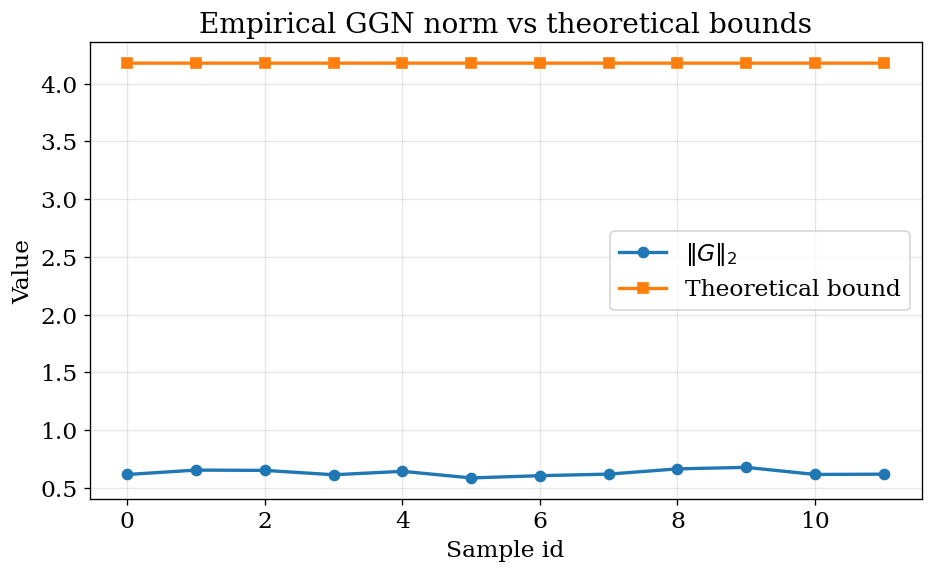

In [71]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(probe_df["sample_id"], probe_df["G_norm"], "o-", label=r"$\|G\|_2$")
ax.plot(probe_df["sample_id"], probe_df["bound_improved"], "s-", label="Theoretical bound")
#ax.plot(probe_df["sample_id"], probe_df["bound_crude_E"], "^-", label="Crude E-bound")

ax.set_xlabel("Sample id")
ax.set_ylabel("Value")
ax.set_title("Empirical GGN norm vs theoretical bounds")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig.savefig(fig_dir / "probe_empirical_vs_bounds.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "probe_empirical_vs_bounds.png", dpi=150, bbox_inches="tight")

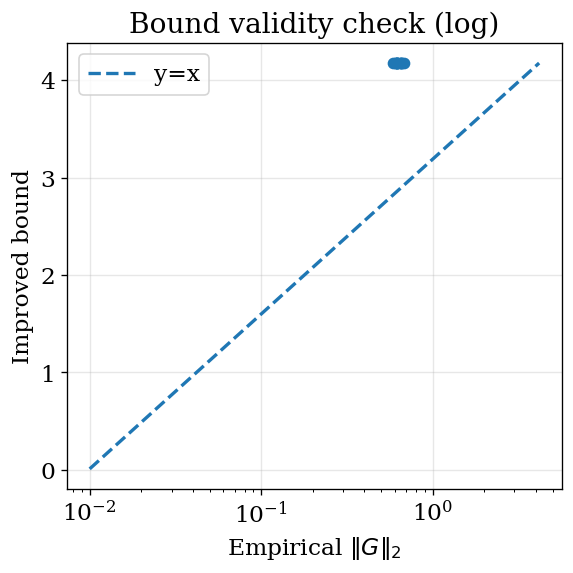

In [58]:
fig, ax = plt.subplots(figsize=(5, 5))

x_vals = probe_df["G_norm"].values
y_vals = probe_df["bound_improved"].values

ax.scatter(x_vals, y_vals)

m = max(x_vals.max(), y_vals.max())
ax.plot([1e-2, m], [1e-2, m], linestyle="--", label="y=x")

ax.set_xscale("log")
#ax.set_yscale("log")
ax.set_xlabel(r"Empirical $\|G\|_2$")
ax.set_ylabel("Improved bound")
ax.set_title("Bound validity check (log)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

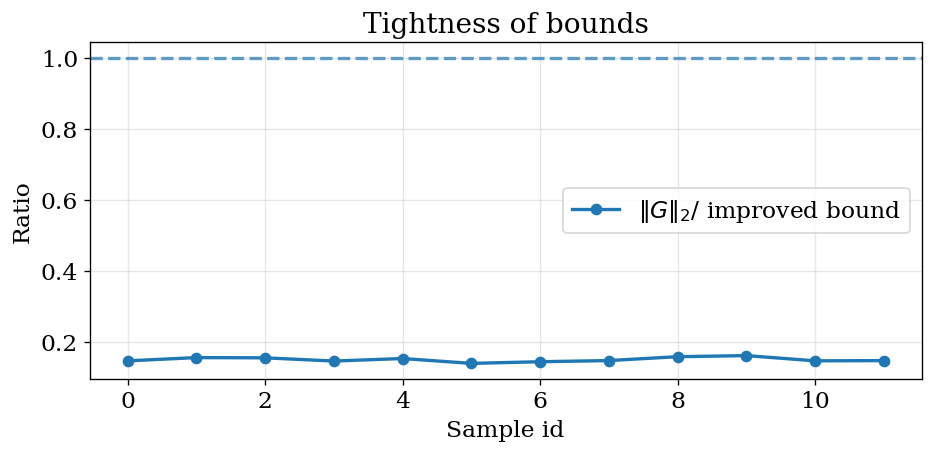

In [59]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(probe_df["sample_id"], probe_df["ratio_improved"], "o-", label=r"$\|G\|_2 /$ improved bound")
#ax.plot(probe_df["sample_id"], probe_df["ratio_crude_E"], "s-", label=r"$\|G\|_2 /$ crude E-bound")
ax.axhline(1.0, linestyle="--", alpha=0.7)

ax.set_xlabel("Sample id")
ax.set_ylabel("Ratio")
ax.set_title("Tightness of bounds")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig.savefig(fig_dir / "bound_tightness_ratios.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "bound_tightness_ratios.png", dpi=150, bbox_inches="tight")

In [60]:
summary = {
    "num_probe": len(probe_df),
    "max_ratio_improved": float(probe_df["ratio_improved"].max()),
    "mean_ratio_improved": float(probe_df["ratio_improved"].mean()),
    "max_ratio_crude_E": float(probe_df["ratio_crude_E"].max()),
    "mean_ratio_crude_E": float(probe_df["ratio_crude_E"].mean()),
}

summary

{'num_probe': 12,
 'max_ratio_improved': 0.16224182778301155,
 'mean_ratio_improved': 0.15097254861810713,
 'max_ratio_crude_E': 0.06195588117778334,
 'mean_ratio_crude_E': 0.05765243929822198}

In [78]:
def run_single_setting(
    E,
    d=16,
    d_ff=32,
    top_k=2,
    gating_type="softmax",
    n_train=2048,
    n_test=512,
    batch_size=64,
    epochs=20,
    lr=1e-3,
    noise_std=0.0,
    num_probe=16,
    power_iters=50,
    power_tol=1e-6,
    base_seed=42,
    device="cpu",
    teacher_model=None,
):
    set_seed(base_seed + E)

    top_k_eff = min(top_k, E)

    teacher, train_loader, test_loader = make_teacher_student_regression_data(
        n_train=n_train,
        n_test=n_test,
        d=d,
        d_ff=d_ff,
        num_experts=E,
        top_k=top_k_eff,
        gating_type=gating_type,
        batch_size=batch_size,
        noise_std=noise_std,
        device=device,
        teacher_model=teacher_model,
    )

    student = StandaloneMoERegressor(
        d=d,
        d_ff=d_ff,
        num_experts=E,
        top_k=top_k_eff,
        gating_type=gating_type,
    ).to(device)

    criterion = HalfSquaredError(reduction="mean")
    optimizer = optim.Adam(student.parameters(), lr=lr)

    history = []
    for epoch in range(epochs):
        train_loss = train_one_epoch_regression(student, train_loader, optimizer, criterion, device)
        test_loss = evaluate_regression(student, test_loader, criterion, device)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "test_loss": test_loss,
        })

    probe_batch_x, probe_batch_y = next(iter(test_loader))
    probe_x = probe_batch_x[:num_probe].to(device)
    probe_y = probe_batch_y[:num_probe].to(device)

    if len(probe_x) < num_probe:
        raise ValueError(f"Probe batch has only {len(probe_x)} samples, expected {num_probe}. Increase batch_size.")

    probe_rows = evaluate_probe_samples(
        model=student,
        probe_x=probe_x,
        probe_y=probe_y,
        loss_fn=criterion,
        device=device,
        power_iters=power_iters,
        power_tol=power_tol,
    )
    probe_df = pd.DataFrame(probe_rows)

    avg_S_g_test = compute_gate_stats(student, test_loader, device)

    summary = {
        "E": E,
        "top_k": top_k_eff,
        "gating_type": gating_type,
        "num_probe": num_probe,

        "final_train_loss": history[-1]["train_loss"],
        "final_test_loss": history[-1]["test_loss"],

        "mean_H_norm": float(probe_df["H_norm"].mean()),
        "mean_G_norm": float(probe_df["G_norm"].mean()),
        "mean_rho": float(probe_df["rho"].mean()),
        "max_rho": float(probe_df["rho"].max()),

        "mean_bound_no_sg": float(probe_df["bound_no_sg"].mean()),
        "mean_bound_theorem": float(probe_df["bound_theorem"].mean()),

        "mean_ratio_no_sg": float(probe_df["ratio_no_sg"].mean()),
        "max_ratio_no_sg": float(probe_df["ratio_no_sg"].max()),

        "mean_ratio_theorem": float(probe_df["ratio_theorem"].mean()),
        "max_ratio_theorem": float(probe_df["ratio_theorem"].max()),

        "mean_S_g_probe": float(probe_df["S_g"].mean()),
        "avg_S_g_test": float(avg_S_g_test),
    }

    return summary, probe_df, history, avg_S_g_test

In [79]:
E_values = [2, 4, 8, 16, 32, 64, 128]

teacher_cfg = dict(
    d=16,
    d_ff=32,
    num_experts=16,
    top_k=16,
    gating_type="softmax",
)

teacher = StandaloneMoERegressor(**teacher_cfg).to(device)
teacher.eval()
for p in teacher.parameters():
    p.requires_grad_(False)

sweep_kwargs = dict(
    d=16,
    d_ff=32,
    gating_type="softmax",
    n_train=2048,
    n_test=512,
    batch_size=64,
    epochs=20,
    lr=1e-3,
    noise_std=0.0,
    num_probe=NUM_PROBE_ARTICLE,
    power_iters=POWER_ITERS_ARTICLE,
    power_tol=POWER_TOL_ARTICLE,
    base_seed=42,
    device=device,
    teacher_model=teacher,
)

In [80]:
sweep_summaries = []
sweep_probe_tables = {}
sweep_histories = {}
gate_stats = {}

for E in E_values:
    print(f"\n=== Running E = {E} ===")

    summary, probe_df_E, history_E, avg_S_g_test = run_single_setting(
        E=E,
        top_k=E,
        **sweep_kwargs,
    )

    sweep_summaries.append(summary)
    sweep_probe_tables[E] = probe_df_E
    sweep_histories[E] = history_E
    gate_stats[E] = avg_S_g_test

    print(
        f"E={E:3d} | "
        f"train={summary['final_train_loss']:.4e} | "
        f"test={summary['final_test_loss']:.4e} | "
        f"mean G={summary['mean_G_norm']:.4e} | "
        f"bound no Sg={summary['mean_bound_no_sg']:.4e} | "
        f"bound theorem={summary['mean_bound_theorem']:.4e} | "
        f"G/theorem={summary['mean_ratio_theorem']:.4f} | "
        f"avg S_g={summary['avg_S_g_test']:.4e}"
    )

sweep_df = pd.DataFrame(sweep_summaries)
sweep_df


=== Running E = 2 ===
E=  2 | train=2.7894e-04 | test=2.9406e-04 | mean G=1.1662e+00 | bound no Sg=2.2051e+00 | bound theorem=2.0207e+00 | G/theorem=0.5770 | avg S_g=5.0356e-01

=== Running E = 4 ===
E=  4 | train=2.0428e-04 | test=2.2890e-04 | mean G=5.4880e-01 | bound no Sg=2.8494e+00 | bound theorem=1.3817e+00 | G/theorem=0.3972 | avg S_g=2.5201e-01

=== Running E = 8 ===
E=  8 | train=1.1364e-04 | test=1.3414e-04 | mean G=2.9008e-01 | bound no Sg=3.7772e+00 | bound theorem=9.8188e-01 | G/theorem=0.2954 | avg S_g=1.2702e-01

=== Running E = 16 ===
E= 16 | train=6.4784e-05 | test=8.5465e-05 | mean G=1.4092e-01 | bound no Sg=5.0496e+00 | bound theorem=7.1915e-01 | G/theorem=0.1960 | avg S_g=6.4398e-02

=== Running E = 32 ===
E= 32 | train=4.7465e-05 | test=6.4265e-05 | mean G=6.9575e-02 | bound no Sg=5.7514e+00 | bound theorem=4.2371e-01 | G/theorem=0.1642 | avg S_g=3.2311e-02

=== Running E = 64 ===
E= 64 | train=3.2372e-05 | test=5.0957e-05 | mean G=3.4719e-02 | bound no Sg=6.3640e

,E,top_k,gating_type,num_probe,final_train_loss,final_test_loss,mean_H_norm,mean_G_norm,mean_rho,max_rho,mean_bound_no_sg,mean_bound_theorem,mean_ratio_no_sg,max_ratio_no_sg,mean_ratio_theorem,max_ratio_theorem,mean_S_g_probe,avg_S_g_test
0,2,2,softmax,16,0.000279,0.000294,1.170010,1.166157,0.996513,1.002907,2.205123,2.020740,0.528840,0.582821,0.577037,0.635436,0.502537,0.503560
1,4,4,softmax,16,0.000204,0.000229,0.546375,0.548797,1.004659,1.039551,2.849445,1.381747,0.192598,0.202946,0.397163,0.417400,0.252511,0.252012
2,8,8,softmax,16,0.000114,0.000134,0.289348,0.290080,1.002602,1.043997,3.777240,0.981883,0.076797,0.083936,0.295439,0.321461,0.127064,0.127023
3,16,16,softmax,16,0.000065,0.000085,0.141694,0.140921,0.994668,1.010156,5.049559,0.719153,0.027908,0.029340,0.195962,0.205676,0.064402,0.064398
4,32,32,softmax,16,0.000047,0.000064,0.069390,0.069575,1.002711,1.019213,5.751398,0.423705,0.012097,0.012500,0.164213,0.168146,0.032267,0.032311
5,64,64,softmax,16,0.000032,0.000051,0.034729,0.034719,0.999721,1.013021,6.363987,0.243085,0.005456,0.005669,0.142822,0.147183,0.016294,0.016284
6,128,128,softmax,16,0.000028,0.000044,0.017362,0.017304,0.996689,1.006488,6.504268,0.123456,0.002660,0.002760,0.140161,0.144843,0.008124,0.008123


In [56]:
sweep_df.to_csv(table_dir / "sweep_E_summary_const_teacher.csv", index=False)

with open(json_dir / "sweep_E_summary_const_teacher.json", "w", encoding="utf-8") as f:
    json.dump(sweep_summaries, f, indent=2)

for E, probe_df_E in sweep_probe_tables.items():
    probe_df_E.to_csv(table_dir / f"probe_results_const_teacher_E_{E}.csv", index=False)

print("Sweep results saved.")

Sweep results saved.


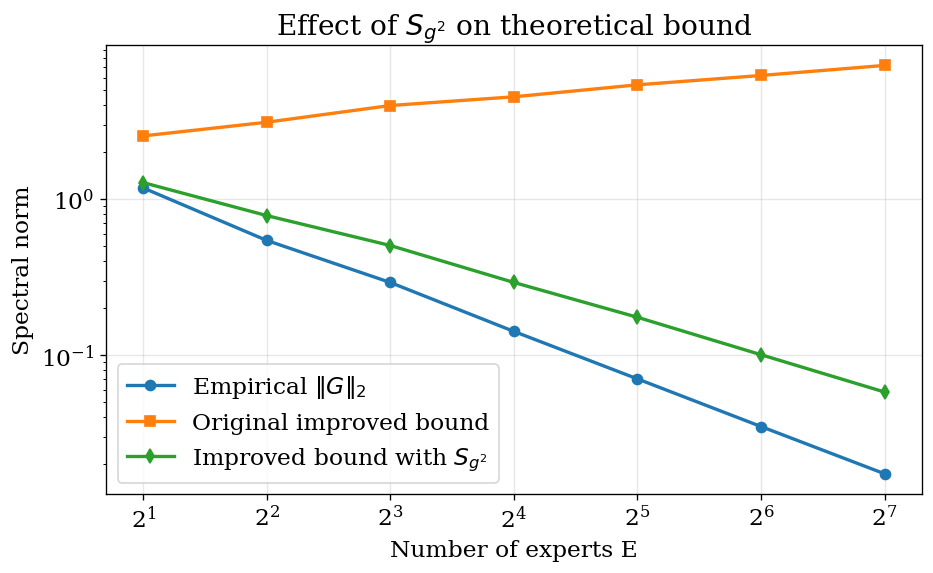

In [54]:
plt.figure(figsize=(8,5))
plt.plot(sweep_df['E'], sweep_df['mean_G_norm'], 'o-', label=r'Empirical $\|G\|_2$')
plt.plot(sweep_df['E'], sweep_df['mean_bound_improved'], 's-', label='Original improved bound')
plt.plot(sweep_df['E'], sweep_df['mean_bound_improved_gates'], 'd-', label='Improved bound with $S_{g^2}$')

plt.xscale('log', base=2)
plt.yscale('log')
plt.xlabel('Number of experts E')
plt.ylabel('Spectral norm')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Effect of $S_{g^2}$ on theoretical bound')
plt.tight_layout()
plt.savefig(fig_dir / "bound_comparison_fixed_teacher.pdf", bbox_inches='tight')
plt.show()

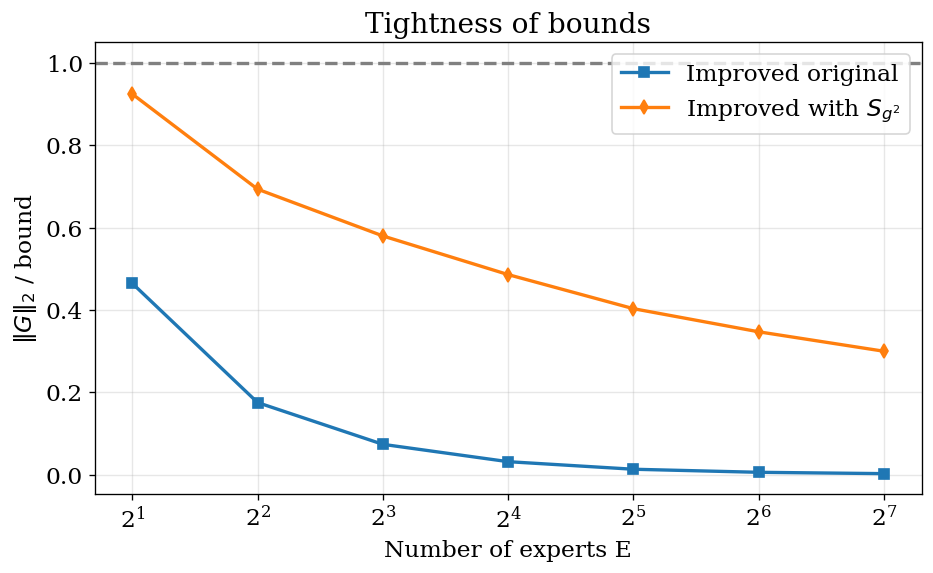

In [55]:
plt.figure(figsize=(8,5))
plt.plot(sweep_df['E'], sweep_df['mean_G_norm'] / sweep_df['mean_bound_improved'], 
         's-', label='Improved original')
plt.plot(sweep_df['E'], sweep_df['mean_G_norm'] / sweep_df['mean_bound_improved_gates'], 
         'd-', label='Improved with $S_{g^2}$')
plt.axhline(1.0, color='gray', linestyle='--')
plt.xscale('log', base=2)
plt.xlabel('Number of experts E')
plt.ylabel(r'$\|G\|_2$ / bound')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Tightness of bounds')
plt.tight_layout()
plt.savefig(fig_dir / "bound_ratios_fixed_teacher.pdf", bbox_inches='tight')
plt.show()

In [45]:
sweep_df.to_csv(table_dir / "sweep_E_summary.csv", index=False)

with open(json_dir / "sweep_E_summary.json", "w", encoding="utf-8") as f:
    json.dump(sweep_summaries, f, indent=2)

for E, probe_df_E in sweep_probe_tables.items():
    probe_df_E.to_csv(table_dir / f"probe_results_E_{E}.csv", index=False)

print("Sweep results saved.")

Sweep results saved.


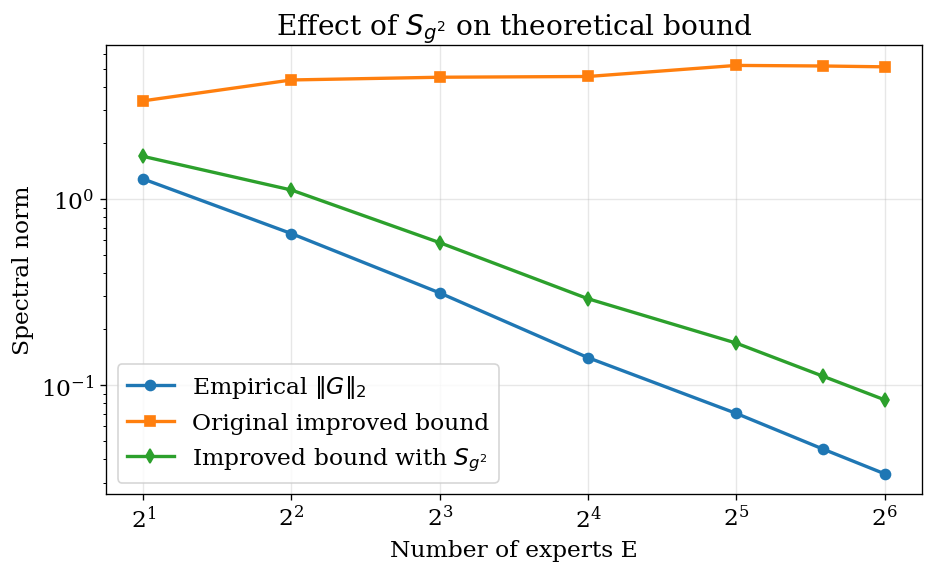

In [43]:
# fig, ax = plt.subplots(figsize=(8, 5))

# ax.plot(sweep_df["E"], sweep_df["mean_G_norm"], "o-", label=r"mean empirical $\|G\|_2$")
# ax.plot(sweep_df["E"], sweep_df["mean_bound_improved"], "s-", label="mean improved bound")
# #ax.plot(sweep_df["E"], sweep_df["mean_bound_crude_E"], "^-", label="mean crude E-bound")


# ax.set_xscale("log")
# ax.set_yscale("log")
# ax.set_xlabel("Number of experts E")
# ax.set_ylabel("Value")
# ax.set_title("Sweep over E: empirical GGN norm vs theoretical bounds")
# ax.set_yscale("log")
# ax.legend()
# ax.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()
plt.figure(figsize=(8,5))
plt.plot(sweep_df['E'], sweep_df['mean_G_norm'], 'o-', label=r'Empirical $\|G\|_2$')
plt.plot(sweep_df['E'], sweep_df['mean_bound_improved'], 's-', label='Original improved bound')
plt.plot(sweep_df['E'], sweep_df['mean_bound_improved_gates'], 'd-', label='Improved bound with $S_{g^2}$')

plt.xscale('log', base=2)
plt.yscale('log')
plt.xlabel('Number of experts E')
plt.ylabel('Spectral norm')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Effect of $S_{g^2}$ on theoretical bound')
plt.tight_layout()
plt.savefig('bound_comparison.pdf', bbox_inches='tight')
plt.show()


# fig.savefig(fig_dir / "sweep_E_empirical_vs_bounds.pdf", bbox_inches="tight")
# fig.savefig(fig_dir / "sweep_E_empirical_vs_bounds.png", dpi=150, bbox_inches="tight")

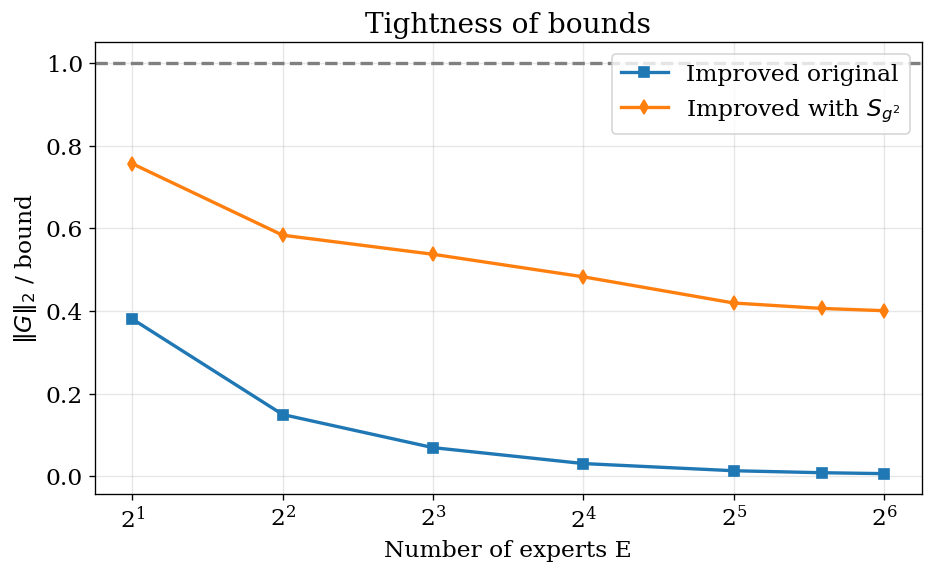

In [44]:
plt.figure(figsize=(8,5))
plt.plot(sweep_df['E'], sweep_df['mean_G_norm'] / sweep_df['mean_bound_improved'], 
         's-', label='Improved original')
plt.plot(sweep_df['E'], sweep_df['mean_G_norm'] / sweep_df['mean_bound_improved_gates'], 
         'd-', label='Improved with $S_{g^2}$')
plt.axhline(1.0, color='gray', linestyle='--')
plt.xscale('log', base=2)
plt.xlabel('Number of experts E')
plt.ylabel(r'$\|G\|_2$ / bound')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Tightness of bounds')
plt.tight_layout()
plt.savefig(fig_dir / "bound_ratios_fixed_teacher.pdf", bbox_inches='tight')
plt.show()

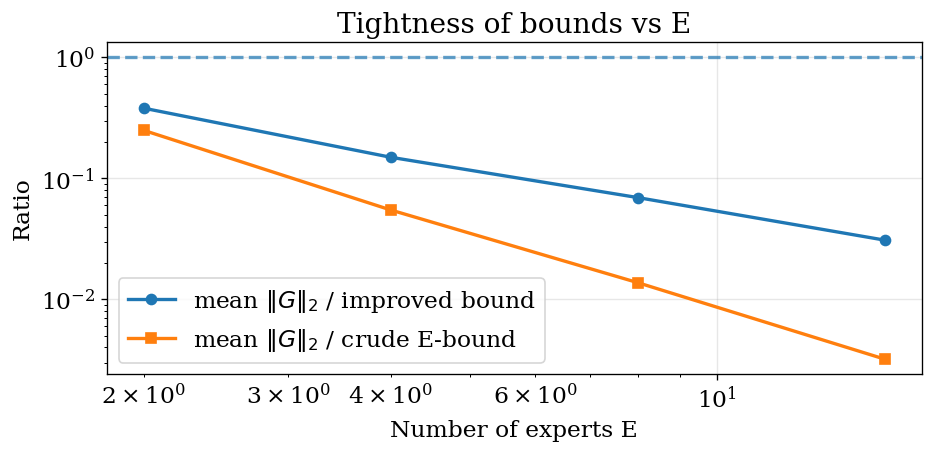

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(sweep_df["E"], sweep_df["mean_ratio_improved"], "o-", label=r"mean $\|G\|_2$ / improved bound")
ax.plot(sweep_df["E"], sweep_df["mean_ratio_crude_E"], "s-", label=r"mean $\|G\|_2$ / crude E-bound")
ax.axhline(1.0, linestyle="--", alpha=0.7)


ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of experts E")
ax.set_ylabel("Ratio")
ax.set_title("Tightness of bounds vs E")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig.savefig(fig_dir / "sweep_E_tightness.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "sweep_E_tightness.png", dpi=150, bbox_inches="tight")

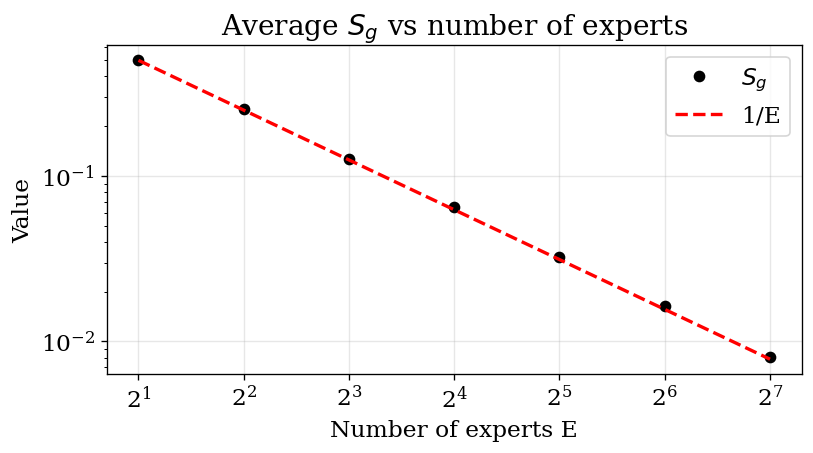

In [67]:
import matplotlib.pyplot as plt
import numpy as np

E_list = [2,4,8,16,32,64,128]
sg_mean = [sweep_probe_tables[E]['S_g2'].mean() for E in E_list]

plt.figure(figsize=(7,4))
plt.plot(E_list, sg_mean, 'o', color='black', label=r'$S_g$')
plt.plot(E_list, 1/np.array(E_list), '--', color='red', label='1/E')

plt.xscale('log', base=2)
plt.yscale('log')
plt.xlabel('Number of experts E')
plt.ylabel('Value')
plt.grid(True, alpha=0.3)
plt.legend()
plt.title('Average $S_g$ vs number of experts')
plt.tight_layout()
plt.savefig(fig_dir / 'Sg_vs_E.pdf', bbox_inches='tight')
plt.show()

In [81]:
sweep_df.to_csv(table_dir / "sweep_E_summary_article.csv", index=False)

with open(json_dir / "sweep_E_summary_article.json", "w", encoding="utf-8") as f:
    json.dump(sweep_summaries, f, indent=2)

for E, probe_df_E in sweep_probe_tables.items():
    probe_df_E.to_csv(table_dir / f"probe_results_article_E_{E}.csv", index=False)

print("Article sweep results saved.")

Article sweep results saved.


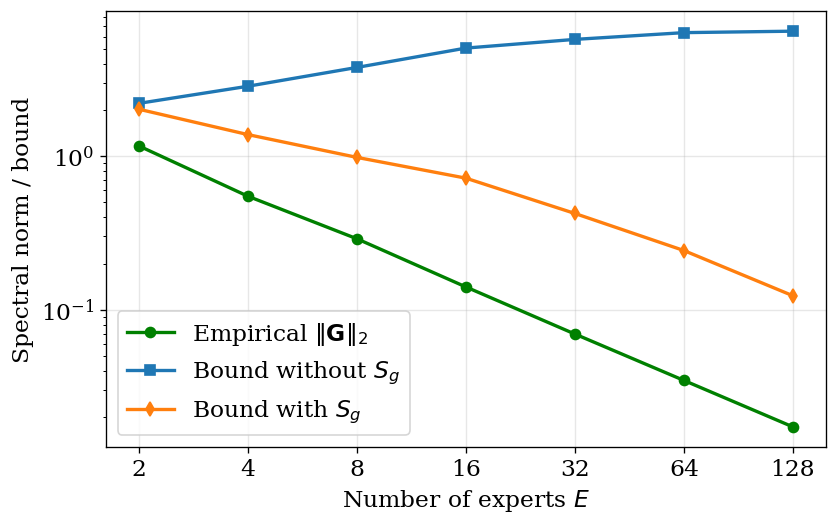

In [95]:
import numpy as np

fig, ax = plt.subplots(figsize=(7.2, 4.6))

ax.plot(
    sweep_df["E"],
    sweep_df["mean_G_norm"],
    "o-",
    label=r"Empirical $\Vert \mathbf{G}\Vert_2$",
    color="green",
)

ax.plot(
    sweep_df["E"],
    sweep_df["mean_bound_no_sg"],
    "s-",
    label=r"Bound without $S_g$",
    color="tab:blue",
)

ax.plot(
    sweep_df["E"],
    sweep_df["mean_bound_theorem"],
    "d-",
    label=r"Bound with $S_g$",
    color="tab:orange",
)

ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xticks(E_values)
ax.set_xticklabels([str(E) for E in E_values])

ax.set_xlabel(r"Number of experts $E$")
ax.set_ylabel(r"Spectral norm / bound")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

fig.savefig(fig_dir / "bound_comparison_article.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "bound_comparison_article.png", dpi=300, bbox_inches="tight")

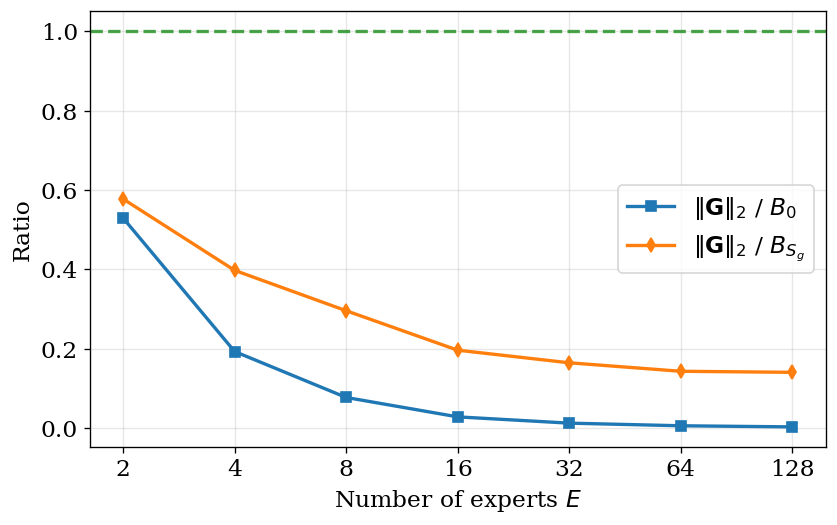

In [94]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))

ax.plot(
    sweep_df["E"],
    sweep_df["mean_ratio_no_sg"],
    "s-",
    label=r"$\Vert\mathbf{G}\Vert_2$ / $B_0$",
    color="tab:blue",
)

ax.plot(
    sweep_df["E"],
    sweep_df["mean_ratio_theorem"],
    "d-",
    label=r"$\Vert \mathbf{G}\Vert_2$ / $B_{S_g}$",
    color="tab:orange"
)

ax.axhline(1.0, linestyle="--", alpha=0.7, color="green")

ax.set_xscale("log", base=2)
ax.set_xticks(E_values)
ax.set_xticklabels([str(E) for E in E_values])

ax.set_xlabel(r"Number of experts $E$")
ax.set_ylabel(r"Ratio")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

fig.savefig(fig_dir / "bound_ratios_article.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "bound_ratios_article.png", dpi=300, bbox_inches="tight")

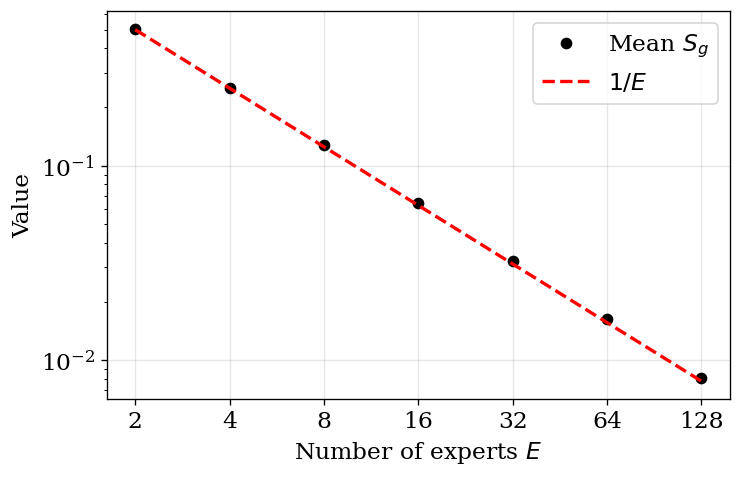

In [87]:
fig, ax = plt.subplots(figsize=(6.4, 4.2))

E_arr = np.array(E_values)

ax.plot(
    sweep_df["E"],
    sweep_df["avg_S_g_test"],
    "o",
    label=r"Mean $S_g$",
    color="black",
)

ax.plot(
    E_arr,
    1 / E_arr,
    "--",
    label=r"$1/E$",
    color="red",
)

ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xticks(E_values)
ax.set_xticklabels([str(E) for E in E_values])

ax.set_xlabel(r"Number of experts $E$")
ax.set_ylabel(r"Value")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

fig.savefig(fig_dir / "Sg_vs_E_article.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "Sg_vs_E_article.png", dpi=300, bbox_inches="tight")

In [90]:
cols = [
    "E",
    "num_probe",
    "mean_G_norm",
    "mean_bound_no_sg",
    "mean_bound_theorem",
    "mean_ratio_no_sg",
    "mean_ratio_theorem",
    "avg_S_g_test",
]

display(sweep_df[cols])

print("max ratio to theorem bound:", sweep_df["max_ratio_theorem"].max())
print("mean ratio to theorem bound:", sweep_df["mean_ratio_theorem"].mean())
print("mean E * S_g:", (sweep_df["E"] * sweep_df["avg_S_g_test"]).mean())

,E,num_probe,mean_G_norm,mean_bound_no_sg,mean_bound_theorem,mean_ratio_no_sg,mean_ratio_theorem,avg_S_g_test
0,2,16,1.166157,2.205123,2.020740,0.528840,0.577037,0.503560
1,4,16,0.548797,2.849445,1.381747,0.192598,0.397163,0.252012
2,8,16,0.290080,3.777240,0.981883,0.076797,0.295439,0.127023
3,16,16,0.140921,5.049559,0.719153,0.027908,0.195962,0.064398
4,32,16,0.069575,5.751398,0.423705,0.012097,0.164213,0.032311
5,64,16,0.034719,6.363987,0.243085,0.005456,0.142822,0.016284
6,128,16,0.017304,6.504268,0.123456,0.002660,0.140161,0.008123


max ratio to theorem bound: 0.6354364626993575
mean ratio to theorem bound: 0.273256830499779
mean E * S_g: 1.0253678389957972
